In [3]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 1.26.4
pandas 2.2.3
sklearn 1.6.0
torch 2.7.1+cpu
cpu


# 数据预处理

In [4]:
# INSERT_YOUR_CODE
from torchvision import datasets, transforms
import os

# 设置数据目录
data_dir = './archive/'

# 定义预处理: resize到128x128, 转为tensor
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4363, 0.4328, 0.3291], std=[0.2427, 0.2382, 0.2413])
])

# 读取训练集和测试集
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'training'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'validation'), transform=transform)

# 获取类别名（方便后续显示标签）
class_names = train_dataset.classes
class_names

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

In [5]:
len(train_dataset)

1097

In [6]:
train_dataset[0][0].shape #特征

torch.Size([3, 128, 128])

In [7]:
train_dataset[0][1] #标签

0

In [8]:
len(test_dataset)

272

In [9]:
# INSERT_YOUR_CODE

# from torch.utils.data import DataLoader
# import torch

# loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=2)

# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0

# for images, _ in loader:  # images: [B, 3, 128, 128]
#     batch_pixels = images.numel() // 3  # total pixels per channel
#     mean += images.sum(dim=[0, 2, 3])
#     std  += (images ** 2).sum(dim=[0, 2, 3])
#     n_pixels += batch_pixels

# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)

# print("按通道均值:", mean)
# print("按通道标准差:", std)



In [10]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)
print(f"批次图像张量形状: {batch_images.shape}")
print(f"批次标签张量形状: {batch_labels.shape}")
print(batch_labels)

训练集DataLoader批次数: 35
测试集DataLoader批次数: 9
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 128, 128])
批次标签张量形状: torch.Size([32])
tensor([0, 1, 2, 3, 5, 5, 8, 1, 4, 3, 7, 2, 0, 5, 0, 1, 2, 2, 5, 6, 1, 1, 5, 1,
        5, 9, 4, 4, 7, 3, 5, 4])


In [11]:
28*28

784

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。

# 搭建模型

In [29]:
128//8

16

In [ ]:
from torchvision.models import resnet50  # 导入torchvision中预训练的ResNet50模型

class ResNet50(nn.Module):
    def __init__(self, num_classes=10, frozen=True):
        super().__init__()
        # 加载预训练的ResNet50模型，并使用官方IMAGENET1K_V2权重
        self.model = resnet50(weights='IMAGENET1K_V2')
        
        # 若frozen为True，则冻结所有参数，不进行梯度更新，只提取特征
        
        # 冻结（freeze）指的是让模型中某些层的参数在训练过程中保持不变，不参与梯度计算和反向传播更新。
        # 在PyTorch中，设置 param.requires_grad = False 就是冻结该参数。
        # 这样做的作用是在迁移学习场景下，利用已经训练好的模型作为特征提取器，仅微调（finetune）模型最后几层以快速适应新任务，提高训练效率并降低对大数据的需求。
        # 通常，低层参数捕捉到通用特征（如边缘、纹理），无需改变；只需训练高层参数以学到与新任务相关的特定特征。
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False  # 冻结所有参数，模型中的所有参数都不参与训练
        
        # 对layer4进行解冻，使其参数可以参与训练（适度微调高层特征）
        for param in self.model.layer4.parameters():
            param.requires_grad = True  # 只解冻Layer4（最后一组卷积层）的参数
            
        # 替换最后的全连接层（原本是1000类），改为自定义的类别数，例如10类
        in_features = self.model.fc.in_features  # 获取原全连接层输入特征数（通常为2048）
        self.model.fc = nn.Linear(in_features, num_classes)  # 用新的全连接层替换
        
    def forward(self, x):
        # 前向传播，直接调用封装好的resnet50模型
        return self.model(x)

# 实例化模型，默认10分类任务，且除了layer4以外全部参数都冻结
model=ResNet50()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\41507/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 28.2MB/s]


In [35]:
128*16*16*256

8388608

In [17]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 128, 128) 
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [41]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
features.0.weight: 864
features.1.weight: 32
features.1.bias: 32
features.3.weight: 9216
features.4.weight: 32
features.4.bias: 32
features.8.weight: 18432
features.9.weight: 64
features.9.bias: 64
features.11.weight: 36864
features.12.weight: 64
features.12.bias: 64
features.16.weight: 73728
features.17.weight: 128
features.17.bias: 128
features.19.weight: 147456
features.20.weight: 128
features.20.bias: 128
features.24.weight: 294912
features.25.weight: 256
features.25.bias: 256
features.27.weight: 589824
features.28.weight: 256
features.28.bias: 256
classifier.1.weight: 32768
classifier.1.bias: 128
classifier.4.weight: 1280
classifier.4.bias: 10
模型总参数量: 1207402


In [16]:
32*3*3*64

18432

# 训练

In [17]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.SGD(model.parameters(), lr=0.001)


In [ ]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 500] Val Loss: 2.3036 Val Acc: 0.1000
[Step 1000] Val Loss: 2.3034 Val Acc: 0.1000
[Step 1500] Val Loss: 2.3033 Val Acc: 0.1000
Epoch [1/20]  Train Loss: 2.3034  Train Acc: 0.1013
[Step 2000] Val Loss: 2.3031 Val Acc: 0.1000
[Step 2500] Val Loss: 2.3030 Val Acc: 0.1000
[Step 3000] Val Loss: 2.3029 Val Acc: 0.1000
[Step 3500] Val Loss: 2.3028 Val Acc: 0.1000
Epoch [2/20]  Train Loss: 2.3030  Train Acc: 0.1000
[Step 4000] Val Loss: 2.3027 Val Acc: 0.1000
[Step 4500] Val Loss: 2.3027 Val Acc: 0.1000
[Step 5000] Val Loss: 2.3026 Val Acc: 0.1000
[Step 5500] Val Loss: 2.3025 Val Acc: 0.1000
Epoch [3/20]  Train Loss: 2.3026  Train Acc: 0.1052
[Step 6000] Val Loss: 2.3024 Val Acc: 0.1000
[Step 6500] Val Loss: 2.3023 Val Acc: 0.1104
[Step 7000] Val Loss: 2.3023 Val Acc: 0.1384
[Step 7500] Val Loss: 2.3022 Val Acc: 0.1000
Epoch [4/20]  Train Loss: 2.3023  Train Acc: 0.1124
[Step 8000] Val Loss: 2.3021 Val Acc: 0.1681
[Step 8500] Val Loss: 2.3020 Val Acc: 0.1000
[Step 9000] Val Loss: 2.3020

KeyboardInterrupt: 

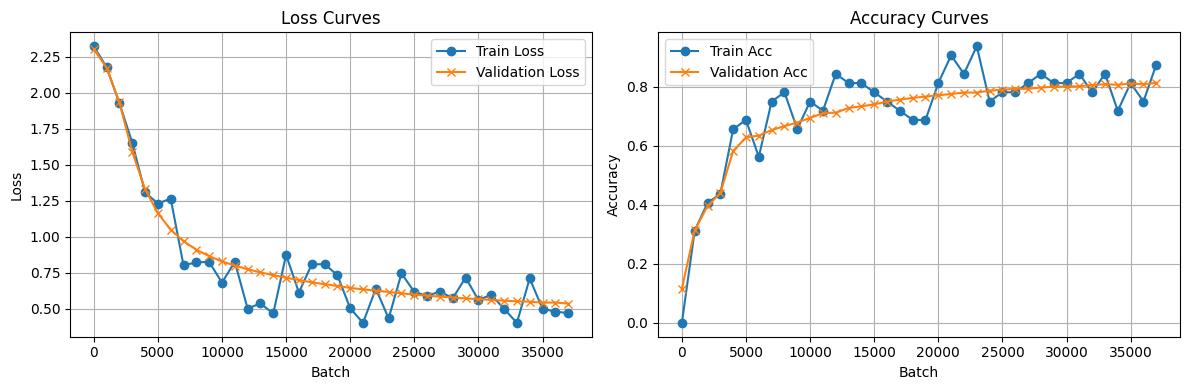

In [ ]:
# trainer.plot_curves()
